In [121]:
import openmeteo_requests

In [122]:
import openmeteo_requests

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests_cache
from retry_requests import retry

In [123]:
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  GRU, LSTM ,Dense

In [124]:
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"daily": ["weather_code", "temperature_2m_max", "temperature_2m_min", "sunrise", "sunset", "uv_index_max", "wind_speed_10m_max", "wind_gusts_10m_max", "shortwave_radiation_sum"],
	"past_days": 92,
	"forecast_hours": 12,
	"past_hours": 1,
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_weather_code = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(2).ValuesAsNumpy()
daily_sunrise = daily.Variables(3).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(4).ValuesInt64AsNumpy()
daily_uv_index_max = daily.Variables(5).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(6).ValuesAsNumpy()
daily_wind_gusts_10m_max = daily.Variables(7).ValuesAsNumpy()
daily_shortwave_radiation_sum = daily.Variables(8).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["weather_code"] = daily_weather_code
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset
daily_data["uv_index_max"] = daily_uv_index_max
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
daily_data["shortwave_radiation_sum"] = daily_shortwave_radiation_sum

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe)

Coordinates: 52.52000045776367°N 13.419998168945312°E
Elevation: 38.0 m asl
Timezone difference to GMT+0: 0s

Daily data
                         date  weather_code  temperature_2m_max  \
0  2025-12-02 00:00:00+00:00           NaN                 NaN   
1  2025-12-03 00:00:00+00:00           NaN                 NaN   
2  2025-12-04 00:00:00+00:00           NaN                 NaN   
3  2025-12-05 00:00:00+00:00           NaN                 NaN   
4  2025-12-06 00:00:00+00:00           NaN                 NaN   
..                       ...           ...                 ...   
94 2026-03-06 00:00:00+00:00           0.0           16.338999   
95 2026-03-07 00:00:00+00:00           3.0           16.338999   
96 2026-03-08 00:00:00+00:00           2.0           16.739000   
97 2026-03-09 00:00:00+00:00           2.0           16.869501   
98 2026-03-10 00:00:00+00:00          80.0           18.169500   

    temperature_2m_min     sunrise      sunset  uv_index_max  \
0                  Na

In [125]:
data = hourly_dataframe

In [126]:
data

,date,temperature_2m,rain,weather_code,visibility,wind_speed_10m,temperature_180m,soil_temperature_6cm,dew_point_2m,relative_humidity_2m
0,2026-03-04 14:00:00+00:00,11.6455,0.0,0.0,44560.0,7.594207,8.945499,14.445499,-3.705858,34.0
1,2026-03-04 15:00:00+00:00,11.6455,0.0,0.0,44440.0,6.214563,9.245500,14.045500,-3.705858,34.0
2,2026-03-04 16:00:00+00:00,11.2455,0.0,0.0,43840.0,6.162207,9.145500,13.045500,-3.294607,36.0
3,2026-03-04 17:00:00+00:00,10.3455,0.0,0.0,42620.0,5.588703,8.745500,11.595500,-2.022331,42.0
4,2026-03-04 18:00:00+00:00,9.1455,0.0,0.0,41700.0,4.213692,8.245500,10.295500,-1.300238,48.0
5,2026-03-04 19:00:00+00:00,7.8955,0.0,0.0,40760.0,3.219938,8.045500,9.245500,-0.347836,56.0
6,2026-03-04 20:00:00+00:00,6.7955,0.0,0.0,39720.0,3.054701,7.745500,8.395500,0.018788,62.0
7,2026-03-04 21:00:00+00:00,5.8955,0.0,0.0,38600.0,2.902413,7.545500,7.695500,0.233716,67.0
8,2026-03-04 22:00:00+00:00,4.8955,0.0,0.0,35720.0,3.219938,7.245500,7.045500,0.648474,74.0
9,2026-03-04 23:00:00+00:00,4.1955,0.0,0.0,33000.0,3.075841,7.045500,6.495500,0.700156,78.0


In [127]:
df=data.fillna(0)
df

,date,temperature_2m,rain,weather_code,visibility,wind_speed_10m,temperature_180m,soil_temperature_6cm,dew_point_2m,relative_humidity_2m
0,2026-03-04 14:00:00+00:00,11.6455,0.0,0.0,44560.0,7.594207,8.945499,14.445499,-3.705858,34.0
1,2026-03-04 15:00:00+00:00,11.6455,0.0,0.0,44440.0,6.214563,9.245500,14.045500,-3.705858,34.0
2,2026-03-04 16:00:00+00:00,11.2455,0.0,0.0,43840.0,6.162207,9.145500,13.045500,-3.294607,36.0
3,2026-03-04 17:00:00+00:00,10.3455,0.0,0.0,42620.0,5.588703,8.745500,11.595500,-2.022331,42.0
4,2026-03-04 18:00:00+00:00,9.1455,0.0,0.0,41700.0,4.213692,8.245500,10.295500,-1.300238,48.0
5,2026-03-04 19:00:00+00:00,7.8955,0.0,0.0,40760.0,3.219938,8.045500,9.245500,-0.347836,56.0
6,2026-03-04 20:00:00+00:00,6.7955,0.0,0.0,39720.0,3.054701,7.745500,8.395500,0.018788,62.0
7,2026-03-04 21:00:00+00:00,5.8955,0.0,0.0,38600.0,2.902413,7.545500,7.695500,0.233716,67.0
8,2026-03-04 22:00:00+00:00,4.8955,0.0,0.0,35720.0,3.219938,7.245500,7.045500,0.648474,74.0
9,2026-03-04 23:00:00+00:00,4.1955,0.0,0.0,33000.0,3.075841,7.045500,6.495500,0.700156,78.0


In [128]:
df["date"] = pd.to_datetime(df["date"])
df["date"] = df["date"].dt.date
df

,date,temperature_2m,rain,weather_code,visibility,wind_speed_10m,temperature_180m,soil_temperature_6cm,dew_point_2m,relative_humidity_2m
0,2026-03-04,11.6455,0.0,0.0,44560.0,7.594207,8.945499,14.445499,-3.705858,34.0
1,2026-03-04,11.6455,0.0,0.0,44440.0,6.214563,9.245500,14.045500,-3.705858,34.0
2,2026-03-04,11.2455,0.0,0.0,43840.0,6.162207,9.145500,13.045500,-3.294607,36.0
3,2026-03-04,10.3455,0.0,0.0,42620.0,5.588703,8.745500,11.595500,-2.022331,42.0
4,2026-03-04,9.1455,0.0,0.0,41700.0,4.213692,8.245500,10.295500,-1.300238,48.0
5,2026-03-04,7.8955,0.0,0.0,40760.0,3.219938,8.045500,9.245500,-0.347836,56.0
6,2026-03-04,6.7955,0.0,0.0,39720.0,3.054701,7.745500,8.395500,0.018788,62.0
7,2026-03-04,5.8955,0.0,0.0,38600.0,2.902413,7.545500,7.695500,0.233716,67.0
8,2026-03-04,4.8955,0.0,0.0,35720.0,3.219938,7.245500,7.045500,0.648474,74.0
9,2026-03-04,4.1955,0.0,0.0,33000.0,3.075841,7.045500,6.495500,0.700156,78.0


In [129]:
df.isnull().sum()

date                    0
temperature_2m          0
rain                    0
weather_code            0
visibility              0
wind_speed_10m          0
temperature_180m        0
soil_temperature_6cm    0
dew_point_2m            0
relative_humidity_2m    0
dtype: int64

array([[<Axes: title={'center': 'temperature_2m'}>,
        <Axes: title={'center': 'rain'}>,
        <Axes: title={'center': 'weather_code'}>],
       [<Axes: title={'center': 'visibility'}>,
        <Axes: title={'center': 'wind_speed_10m'}>,
        <Axes: title={'center': 'temperature_180m'}>],
       [<Axes: title={'center': 'soil_temperature_6cm'}>,
        <Axes: title={'center': 'dew_point_2m'}>,
        <Axes: title={'center': 'relative_humidity_2m'}>]], dtype=object)

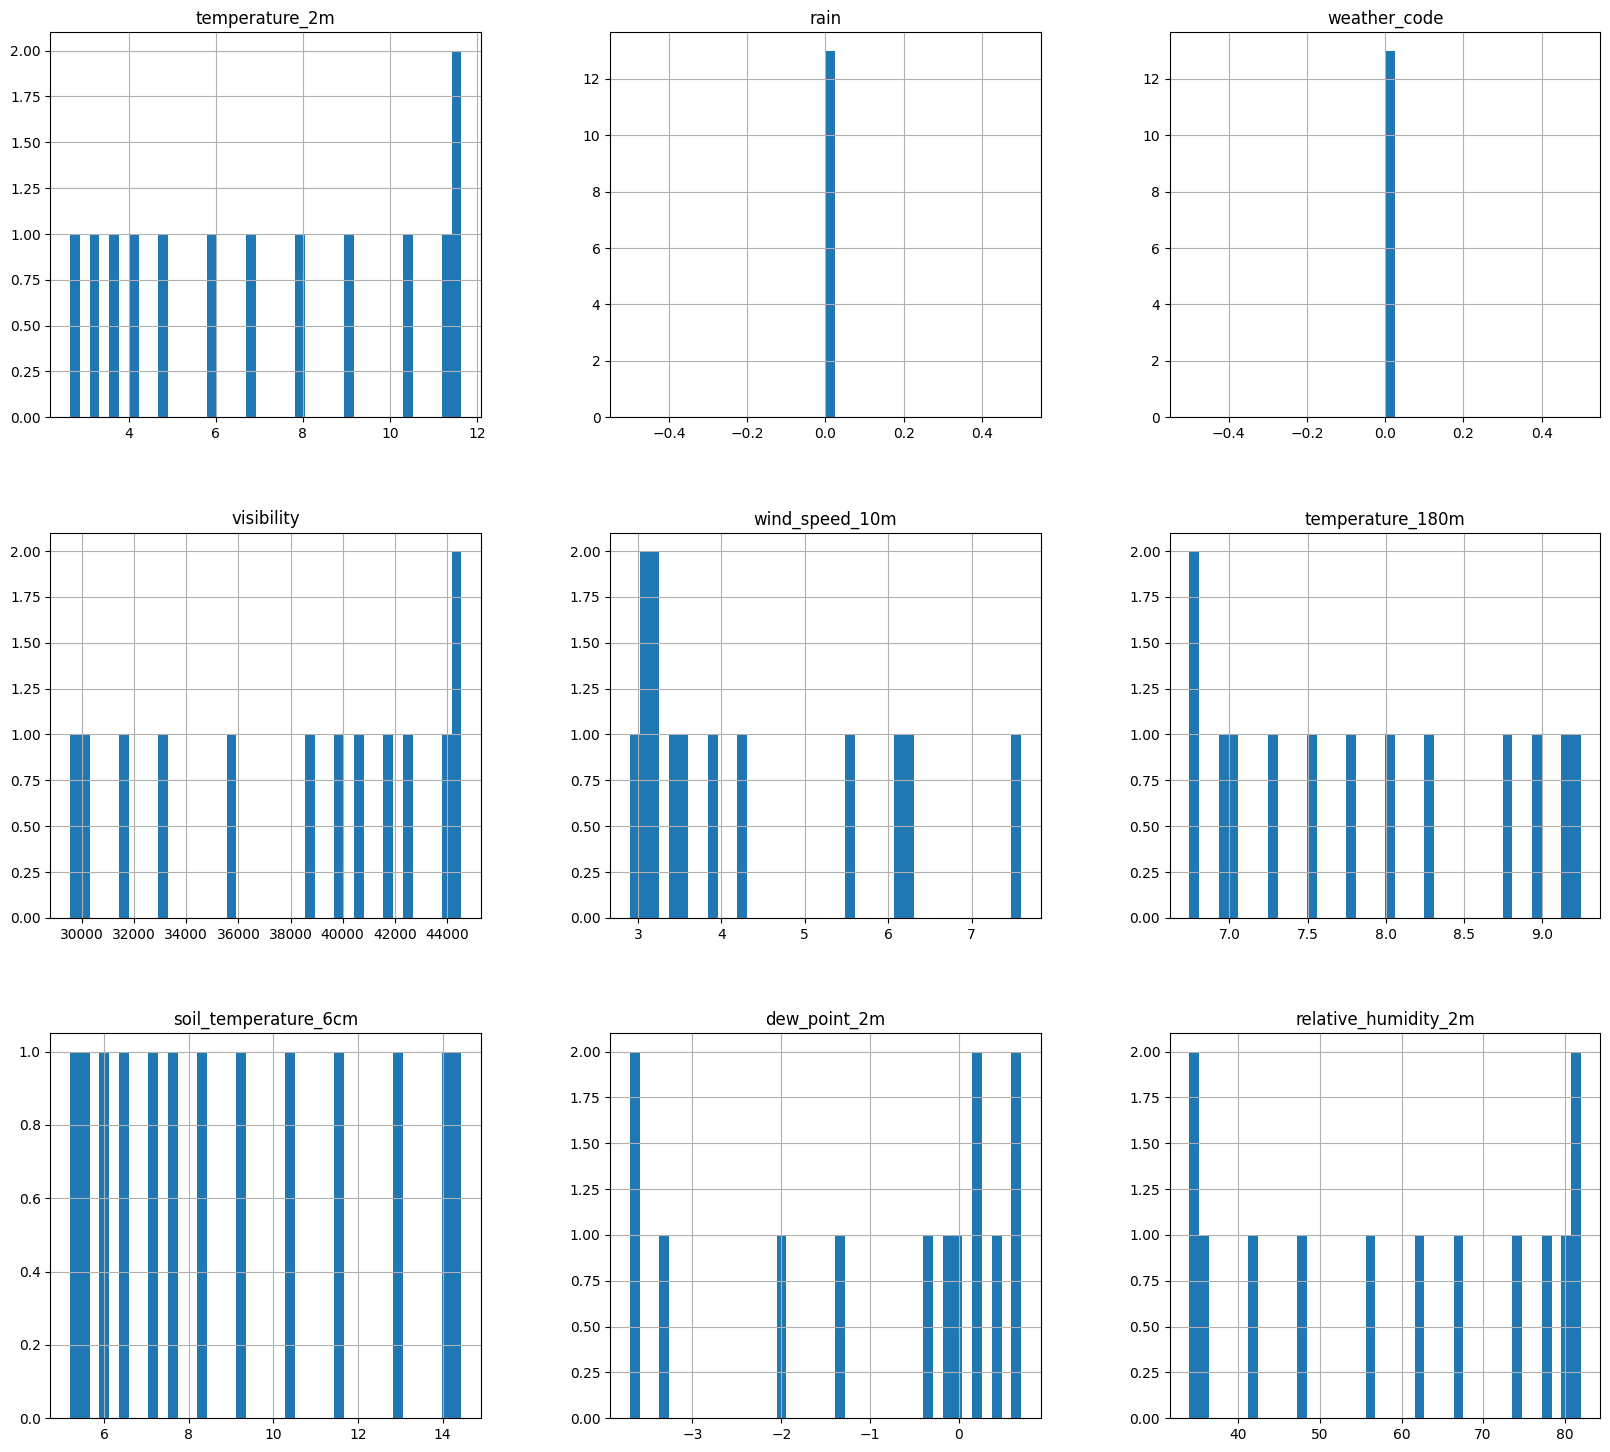

In [130]:
df.hist(bins=40,figsize=(20,18))

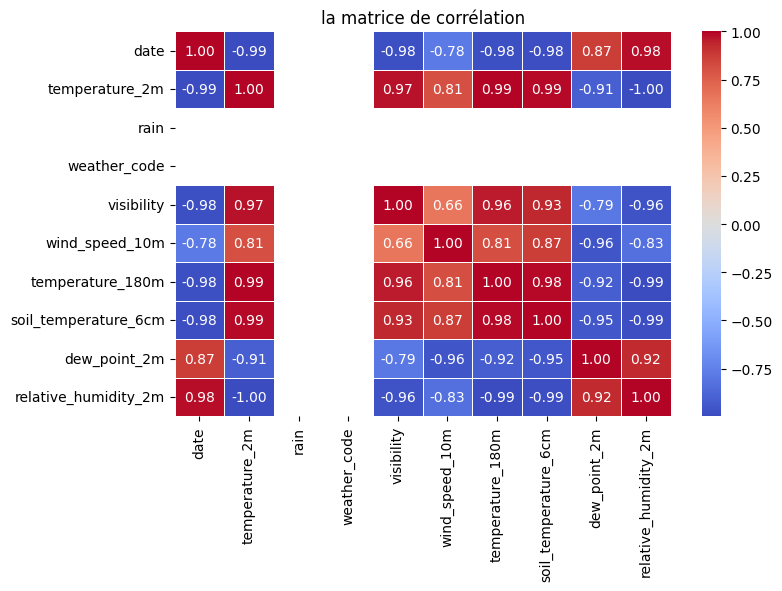

In [131]:
correlation=data.corr()
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True ,cmap="coolwarm" , fmt=".2f", linewidths=0.5)
plt.title("la matrice de corrélation")
plt.show()

In [132]:
df["amplitude_temp"] = df["temperature_2m_max"] - df["temperature_2m_min"]
df

KeyError: 'temperature_2m_max'

In [ ]:
data=df.drop(["temperature_2m_max","temperature_2m_min"], axis=1).copy()
data

,date,weather_code,sunrise,sunset,uv_index_max,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,amplitude_temp
0,2025-12-02,0.0,1764658573,1764687327,0.00,0.000000,0.000000,0.00,0.000000
1,2025-12-03,0.0,1764745058,1764773691,0.00,0.000000,0.000000,0.00,0.000000
2,2025-12-04,0.0,1764831540,1764860058,0.00,0.000000,0.000000,0.00,0.000000
3,2025-12-05,0.0,1764918020,1764946428,0.00,0.000000,0.000000,0.00,0.000000
4,2025-12-06,0.0,1765004497,1765032802,0.00,0.000000,0.000000,0.00,0.000000
...,...,...,...,...,...,...,...,...,...
94,2026-03-06,0.0,1772775679,1772816029,3.10,8.942214,23.039999,11.69,14.443499
95,2026-03-07,3.0,1772861942,1772902538,3.20,5.052841,14.040000,10.62,15.899999
96,2026-03-08,2.0,1772948204,1772989047,3.25,13.183080,31.680000,9.24,11.950001
97,2026-03-09,2.0,1773034465,1773075556,3.10,13.281023,32.399998,11.73,14.270126


In [ ]:
df_numeric = df.drop(columns=["date"])
df_numeric

,weather_code,temperature_2m_max,temperature_2m_min,sunrise,sunset,uv_index_max,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,amplitude_temp
0,0.0,0.000000,0.000000,1764658573,1764687327,0.00,0.000000,0.000000,0.00,0.000000
1,0.0,0.000000,0.000000,1764745058,1764773691,0.00,0.000000,0.000000,0.00,0.000000
2,0.0,0.000000,0.000000,1764831540,1764860058,0.00,0.000000,0.000000,0.00,0.000000
3,0.0,0.000000,0.000000,1764918020,1764946428,0.00,0.000000,0.000000,0.00,0.000000
4,0.0,0.000000,0.000000,1765004497,1765032802,0.00,0.000000,0.000000,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...
94,0.0,16.338999,1.895500,1772775679,1772816029,3.10,8.942214,23.039999,11.69,14.443499
95,3.0,16.338999,0.439000,1772861942,1772902538,3.20,5.052841,14.040000,10.62,15.899999
96,2.0,16.739000,4.789000,1772948204,1772989047,3.25,13.183080,31.680000,9.24,11.950001
97,2.0,16.869501,2.599375,1773034465,1773075556,3.10,13.281023,32.399998,11.73,14.270126


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler_series=scaler.fit_transform(df_numeric)


In [ ]:
x=df_numeric.drop(columns=["amplitude_temp"])
y=df_numeric["amplitude_temp"]

In [ ]:
model = Sequential()
model.add(Dense(16, input_dim=x.shape[1],  activation='relu'))
model.add(Dense(8,  activation='relu')) 
model.add(Dense(4,  activation='relu'))
model.add(Dense(1,  activation='sigmoid'))
        # Compile model
model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

c:\Users\samya.taqi\Desktop\SAMYA TAQI\samya.taqi\deepleraning_computervision\deepenvv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [133]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013 (3.96 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 676 (2.64 KB)

In [134]:
history=model.fit(x,y,epochs=50)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.0132
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.0277
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.0411
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.0545 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.0695
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.0830 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.0964
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.1102 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.1238 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.1381 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -0.1518 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━

In [138]:
df_train=pd.read_csv("data\DailyDelhiClimateTrain.csv")
df_train

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\samya.taqi\AppData\Local\Temp\ipykernel_8896\3646997060.py:1: SyntaxWarning: invalid escape sequence '\D'
  df_train=pd.read_csv("data\DailyDelhiClimateTrain.csv")


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [139]:
df_train.shape

(1462, 5)